# 05 -- Compare the U-Net and the YOLO

Loads both models trained in notebooks 03/04, runs both on the exact same held-out
`test` chips from `data/split.json`, and puts them side by side -- same source
geometries (notebook 02), same split, same test chips, two different ways of
answering "where are the buildings."

**Both models here are the smoke-test checkpoints** committed in notebooks 03/04
(5 epochs / 15 epochs on 20 chips) -- this notebook's own numbers inherit that same
caveat and are illustrative of *how to compare them*, not a real verdict on which
model is better. Retrain both properly (full dataset, real epoch counts) before
drawing any conclusion from the numbers.

In [1]:
import sys
sys.path.insert(0, '..')

import json

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import segmentation_models_pytorch as smp
import torch
from PIL import Image
from ultralytics import YOLO

from src.split import load_split

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
split = load_split('../data/split.json')
test_ids = split['test']
print('test chips:', test_ids)


test chips: ['101', '1', '1003']


## Load both trained checkpoints

In [2]:
unet = smp.Unet(encoder_name='resnet34', encoder_weights=None, in_channels=3, classes=1).to(DEVICE)
unet.load_state_dict(torch.load('../runs/unet.pt', map_location=DEVICE))
unet.eval()

yolo = YOLO('../runs/runs/yolo/weights/best.pt')
print('both models loaded')


both models loaded


## Run both on every test chip

U-Net gets a binary mask (sigmoid threshold 0.5); YOLO gets boxes (default
confidence threshold). Both run on the same `data/yolo/images/imgX.png` /
`data/unet/images/imgX.png` files, which are pixel-identical (notebook 02 writes
the same `to_uint8_rgb` output to both directories).

In [3]:
def load_unet_input(chip_id):
    img = np.array(Image.open(f'../data/unet/images/img{chip_id}.png').convert('RGB'), dtype='float32') / 255.0
    return torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)


# conf=0.25 is Ultralytics' default confidence threshold. At that threshold
# this 15-epoch smoke-test model predicts zero boxes on every test chip (see
# below) -- an honest, real finding, not a bug: 15 epochs on 14 training images
# isn't enough for the model to be confident about anything. conf=0.01 is used
# alongside it purely so the comparison figure has *something* to show; it is
# not a threshold you would use in a real deployment.
results = {}
for chip_id in test_ids:
    with torch.no_grad():
        pred_mask = torch.sigmoid(unet(load_unet_input(chip_id).to(DEVICE)))[0, 0].cpu().numpy()
    default_pred = yolo.predict(f'../data/yolo/images/img{chip_id}.png', imgsz=256, verbose=False)[0]
    low_conf_pred = yolo.predict(f'../data/yolo/images/img{chip_id}.png', imgsz=256, conf=0.01, verbose=False)[0]
    results[chip_id] = {
        'unet_mask': pred_mask > 0.5,
        'yolo_boxes_default_conf': default_pred.boxes.xyxy.cpu().numpy() if len(default_pred.boxes) else np.zeros((0, 4)),
        'yolo_boxes_low_conf': low_conf_pred.boxes.xyxy.cpu().numpy() if len(low_conf_pred.boxes) else np.zeros((0, 4)),
    }
    print(f'chip {chip_id}: unet building-pixels={results[chip_id]["unet_mask"].mean():.3f}, '
          f'yolo boxes @conf=0.25: {len(results[chip_id]["yolo_boxes_default_conf"])}, '
          f'@conf=0.01: {len(results[chip_id]["yolo_boxes_low_conf"])}')


chip 101: unet building-pixels=0.776, yolo boxes @conf=0.25: 0, @conf=0.01: 51


chip 1: unet building-pixels=0.950, yolo boxes @conf=0.25: 0, @conf=0.01: 29


chip 1003: unet building-pixels=0.199, yolo boxes @conf=0.25: 0, @conf=0.01: 33


## Side by side, one figure per test chip: image | ground truth | U-Net | YOLO

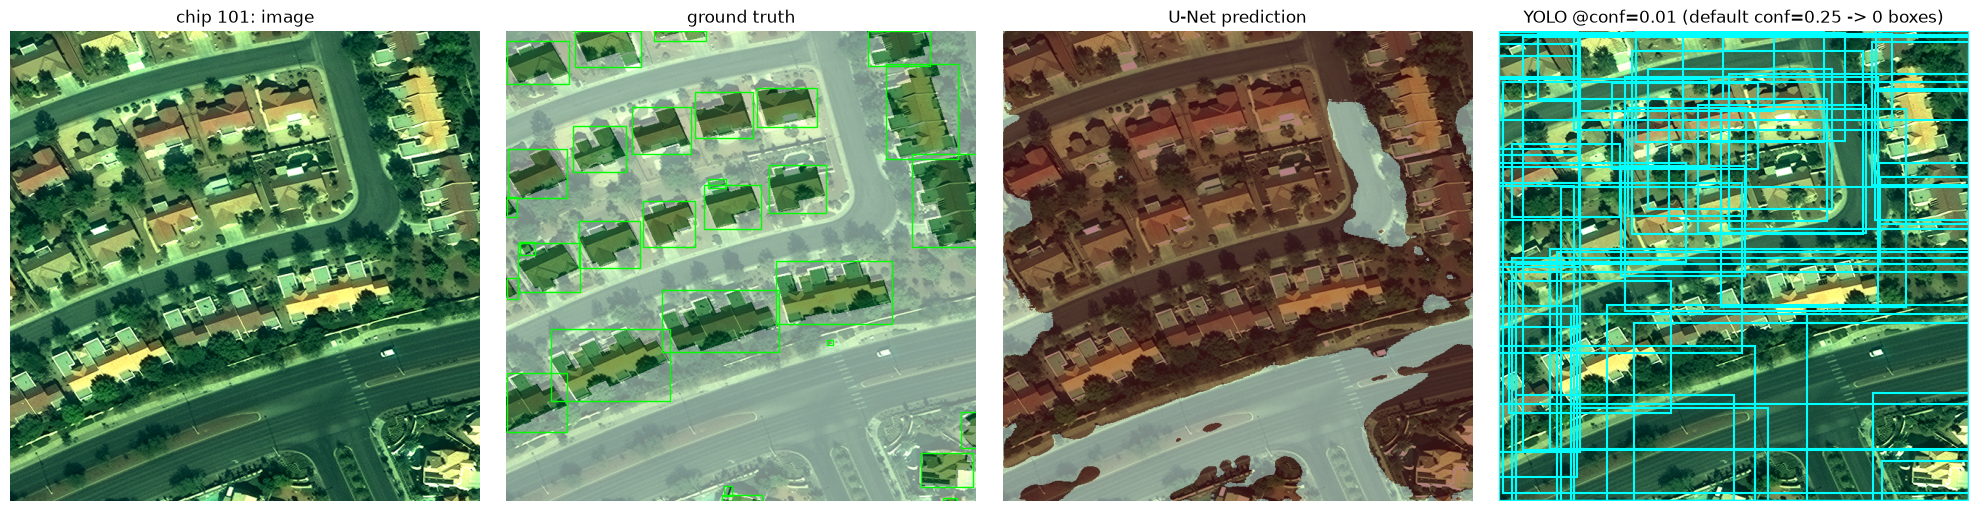

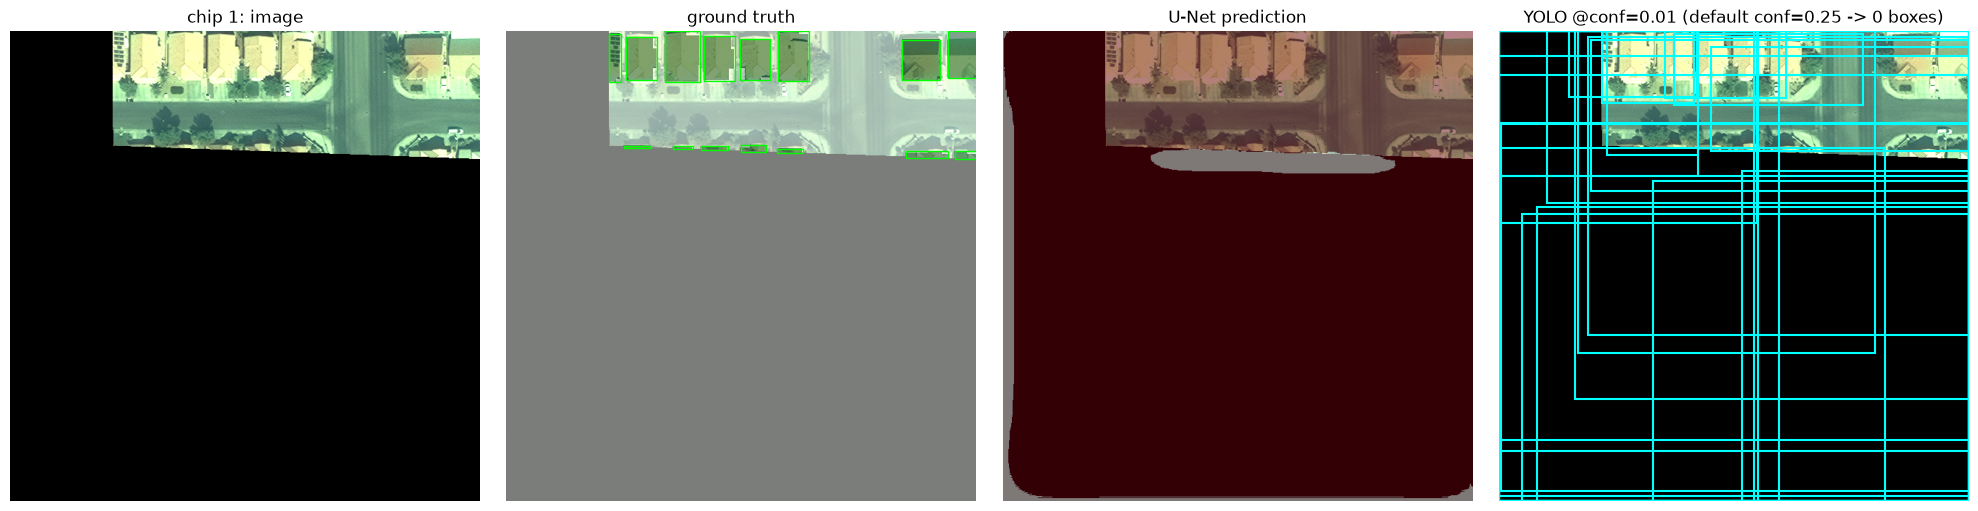

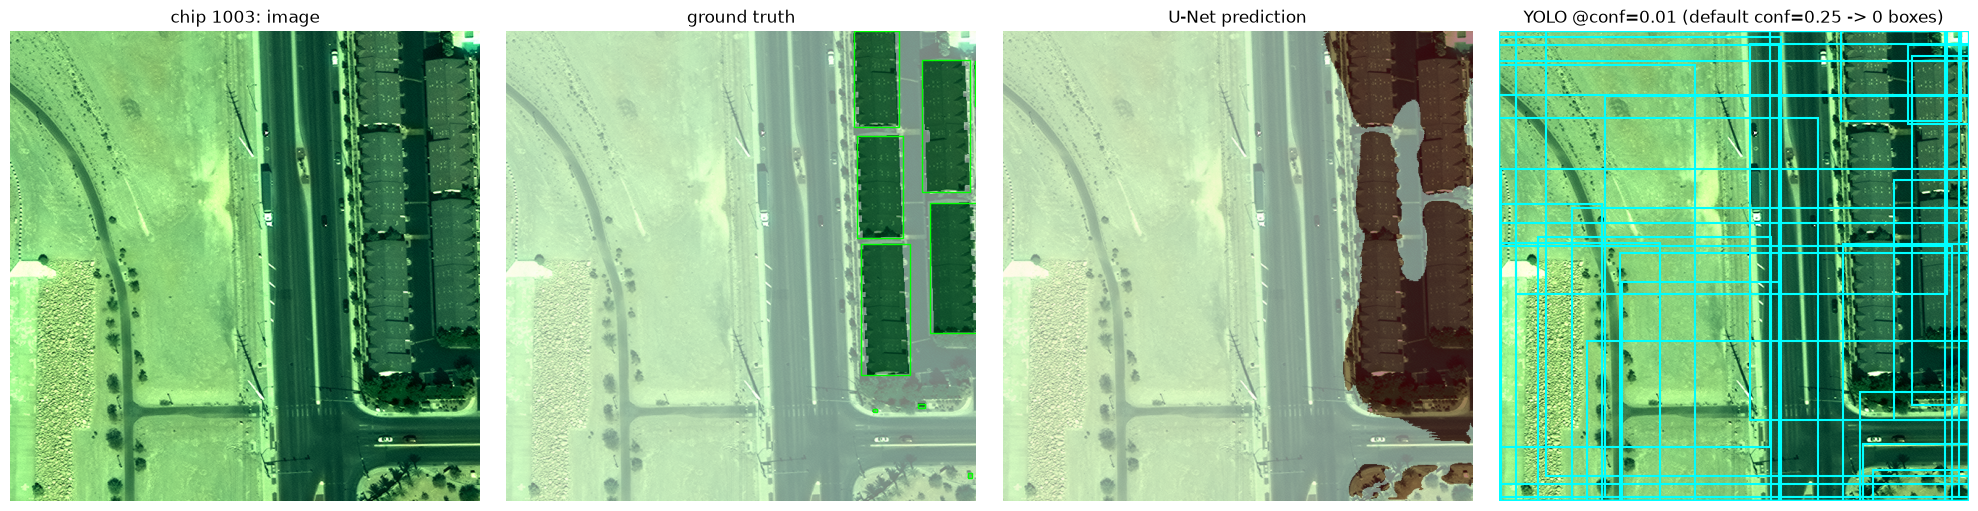

In [4]:
for chip_id in test_ids:
    img = np.array(Image.open(f'../data/unet/images/img{chip_id}.png'))
    true_mask = np.array(Image.open(f'../data/unet/masks/img{chip_id}.png'))
    with open(f'../data/yolo/labels/img{chip_id}.txt') as f:
        true_lines = [ln.split() for ln in f.read().splitlines() if ln.strip()]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(img); axes[0].set_title(f'chip {chip_id}: image')

    axes[1].imshow(img); axes[1].imshow(true_mask, alpha=0.5, cmap='Greens')
    axes[1].set_title('ground truth')
    h, w = true_mask.shape
    for _, x, y, bw, bh in true_lines:
        x, y, bw, bh = float(x) * w, float(y) * h, float(bw) * w, float(bh) * h
        axes[1].add_patch(patches.Rectangle((x - bw / 2, y - bh / 2), bw, bh, linewidth=1, edgecolor='lime', facecolor='none'))

    axes[2].imshow(img); axes[2].imshow(results[chip_id]['unet_mask'], alpha=0.5, cmap='Reds')
    axes[2].set_title('U-Net prediction')

    n_default = len(results[chip_id]['yolo_boxes_default_conf'])
    axes[3].imshow(img)
    axes[3].set_title(f'YOLO @conf=0.01 (default conf=0.25 -> {n_default} boxes)')
    for x1, y1, x2, y2 in results[chip_id]['yolo_boxes_low_conf']:
        axes[3].add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=1.5, edgecolor='cyan', facecolor='none'))

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


## Metrics table (from notebooks 03/04's own held-out test evaluation)

In [5]:
unet_metrics = json.load(open('../runs/unet_metrics.json'))
yolo_metrics = json.load(open('../runs/yolo_metrics.json'))

print(f"{'model':<8} {'metric':<14} {'value':<8} {'epochs'}")
print(f"{'U-Net':<8} {'test IoU':<14} {unet_metrics['test_iou']:<8.3f} {unet_metrics['epochs']}")
print(f"{'U-Net':<8} {'test F1':<14} {unet_metrics['test_f1']:<8.3f} {unet_metrics['epochs']}")
print(f"{'YOLO':<8} {'test mAP50':<14} {yolo_metrics['test_map50']:<8.3f} {yolo_metrics['epochs']}")
print(f"{'YOLO':<8} {'mAP50-95':<14} {yolo_metrics['test_map50_95']:<8.3f} {yolo_metrics['epochs']}")


model    metric         value    epochs
U-Net    test IoU       0.280    5
U-Net    test F1        0.400    5
YOLO     test mAP50     0.075    15
YOLO     mAP50-95       0.024    15


## Which tool for which question

These two models don't answer the same question, which is the actual point of this
practice repo -- same dataset, same source geometries, deliberately different task
framing:

- **U-Net (semantic segmentation)** answers *"which pixels are building?"* -- output
  is a per-pixel mask. Good when you need building **footprint area/shape**
  (e.g. estimating built-up area, footprint size for flood-exposure modeling), or
  when buildings touch/overlap and individual instances don't matter. Doesn't tell
  you *how many* buildings are in a blob of connected mask pixels without an extra
  connected-components step.
- **YOLO (object detection)** answers *"where are the individual buildings, and how
  many?"* -- output is one box per building instance, with a confidence score.
  Good when you need a **building count** or per-building candidates to follow up on
  (e.g. counting structures in an area for population-density proxies, or flagging
  individual buildings for field verification). Boxes are a coarser shape descriptor
  than a mask -- a box around an L-shaped building includes non-building area.
- **A concrete illustration of the smoke-test caveat**: at Ultralytics' default
  confidence threshold (0.25), this 15-epoch YOLO checkpoint predicts **zero boxes**
  on all three held-out test chips -- visible directly in the printed counts and the
  figures above (which fall back to conf=0.01 just so there's something to draw).
  The non-zero mAP50=0.075 isn't inconsistent with this: mAP is computed by sweeping
  confidence thresholds down to near zero, so it can register a few correct
  low-confidence boxes that a real deployment (using the default threshold) would
  never surface. This is exactly why the notebook 03/04 caveats insist on retraining
  before reading anything into these numbers -- a model this undertrained isn't
  usable at realistic settings even though its benchmark number is nonzero.

For a real dengue/flood-risk building-footprint pipeline (see the companion
`project_geohealth_ai` plan), the segmentation mask is closer to what's actually
needed -- footprint polygons for exposure area, not just building counts -- which is
why that plan's own H-phase track leads with U-Net-family models rather than YOLO.

## Done when

- [ ] Both models retrained on the full downloaded dataset with real epoch counts
  (see notebooks 03/04's own "Done when" checklists).
- [ ] This notebook re-run against those real checkpoints -- the numbers and figures
  above are smoke-test placeholders, not a real comparison.
- [ ] `RESULTS.md` at the repo root updated with the real numbers and figures.